Neuroinformatics Project by Magnus Prinz; 1003665

Installing the packages:

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance, entropy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report
from scipy.fftpack import fft
from sklearn.decomposition import PCA

Loading the data:

In [3]:
x = np.load(r"C:\Users\Admin\Desktop\neuroinfo\x.npy")
y = np.load(r"C:\Users\Admin\Desktop\neuroinfo\y.npy")

Visualizes the neural activity of all neurons over time for a selected trial.

Parameters:

x : np.ndarray

    3D array of shape (trials, neurons, time_bins),
    representing neural firing activity.
y : np.ndarray

    1D array of shape (trials,), containing class labels
    (0 = familiar, 1 = unfamiliar).
idx : int, optional

    Index of the trial to visualize. Default is 0.
    

In [4]:
# To plot the firing rate of neurons over time for a few trials
def sample_trial(x, y, idx = 0):
    sample_idx = idx  # Change this to see different trials
    neural_activity = x[sample_idx]  # Shape: (neurons, time)

    # Plotting sample
    plt.figure(figsize=(10, 6))
    plt.imshow(neural_activity, aspect="auto", cmap="hot", interpolation="nearest")
    plt.colorbar(label="Firing rate")
    plt.xlabel("Time")
    plt.ylabel("Neuron index")
    plt.title(f"Neural Activity for Trial {sample_idx} (Label: {y[sample_idx]})")
    plt.show()

The heatmap shows temporal patterns of firing across neurons.
    Brighter white regions = higher firing activity.
    Differences between familiar (0) and unfamiliar (1) trials might appear as distinct spatial/temporal patterns.

    This plot helps in:
    - Qualitative inspection of neural dynamics
    - Spotting highly active neurons
    - Identifying synchrony or silence periods

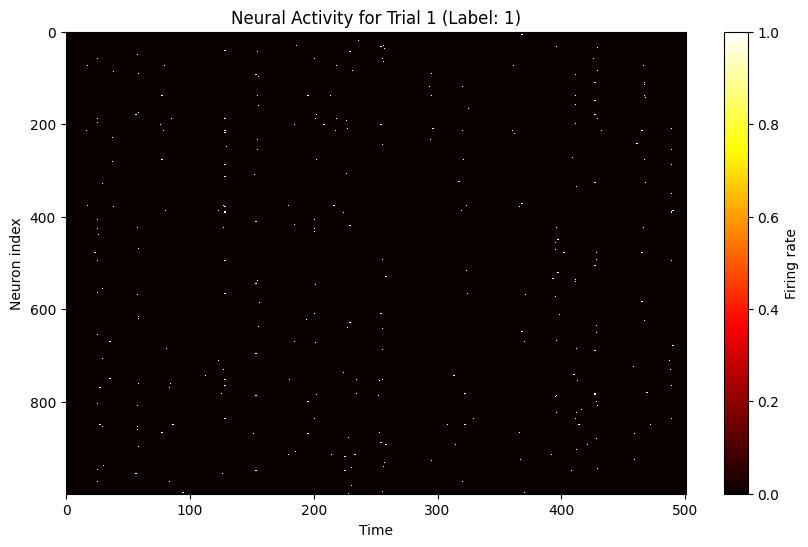

In [8]:
sample_trial(x, y, idx = 1)

Computes and visualizes the average or sum of neural activity over time for familiar and unfamiliar stimuli:

Parameters:
 
x : np.ndarray

    3D array of shape (trials, neurons, time), containing neural firing data.
y : np.ndarray

    1D array of shape (trials,), with binary labels (0 = familiar, 1 = unfamiliar).
firing_rate_mean: boolean

    decides which methods wil be used (T = mean or F = sum)


In [ ]:
# To check if familiar and unfamiliar stimuli produce different neural responses. 
def firing_rate(x, y, firing_rate_mean = True):

    if firing_rate_mean == True:
        # Compute mean firing rate over time for both classes
        mean_familiar = np.mean(x[y == 0], axis=0)  # Average across trials with y=0
        mean_unfamiliar = np.mean(x[y == 1], axis=0)  # Average across trials with y=1
    else:
        # Compute sum of firing rate over time for both classes
        sum_familiar = np.sum(x[y == 0], axis=0)  # Average across trials with y=0
        sum_unfamiliar = np.sum(x[y == 1], axis=0)  # Average across trials with y=1

    if firing_rate_mean == True:
        # Plot the average neural responses
        plt.figure(figsize=(10, 5))
        plt.plot(np.mean(mean_familiar, axis=0), label="Familiar", color="blue")
        plt.plot(np.mean(mean_unfamiliar, axis=0), label="Unfamiliar", color="red")
        plt.xlabel("Time")
        plt.ylabel("Average Firing Rate")
        plt.legend()
        plt.title("Average Neural Activity for Familiar vs Unfamiliar Stimuli")
        plt.show()
    else:
        # Plot the sum of neural responses
        plt.figure(figsize=(10, 5))
        plt.plot(np.sum(sum_familiar, axis=0), label="Familiar", color="blue")
        plt.plot(np.sum(sum_unfamiliar, axis=0), label="Unfamiliar", color="red")
        plt.xlabel("Time")
        plt.ylabel("Sum of Firing Rate")
        plt.legend()
        plt.title("Sum of Neural Activity for Familiar vs Unfamiliar Stimuli")
        plt.show()

Observation (Mean Neural Activity):
- Both responses start at 0 (low/no firing).
- Familiar stimuli stabilize quickly at ~0.0015.
- Unfamiliar stimuli rise higher (~0.0025), suggesting stronger or longer activity.

Observation (Sum Neural Activity):
- Both responses start at 0 (low/no firing).
- Familiar stimuli stabilize quickly at ~600.
- Unfamiliar stimuli rise higher (~1000), suggesting stronger or longer activity.

This suggests that unfamiliar stimuli elicit a more intense or prolonged response across the neuron population — a known phenomenon in novelty detection.


Justification: Using the mean firing rate over time:
- Captures the population response dynamics to different stimulus types.
- Helps determine whether the neural population differentiates familiar vs unfamiliar.
- Provides a clean and interpretable feature (e.g., peak rate, area under curve) for classification.

Justification: Using the sum of firing rate over time:
- The timing details of spikes are less important than the amount of activity.
- You want a simple scalar feature per neuron or trial for classification or visualization.
- You're comparing global responses to familiar vs unfamiliar stimuli.

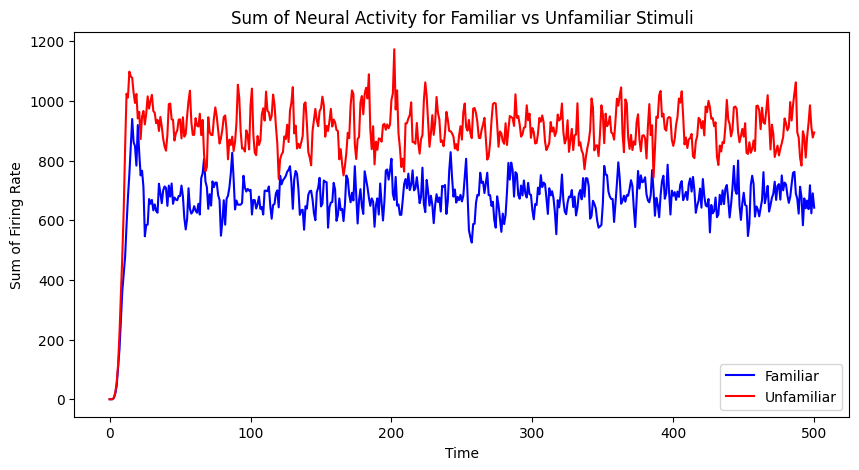

In [ ]:
firing_rate(x, y, True)

Selecting suitable classification:

Justification:

Mean: This captures each neuron's average level of activation, ignoring timing. It's biologically meaningful and compact, ideal when total activity matters more than spike timing.

Sum: Captures the overall "population energy" at each moment in time. Useful when you care more about total engagement than specific neuron identities.

Fourier: Captures frequency-domain characteristics of firing patterns (e.g., oscillatory behavior). Useful if familiar/unfamiliar responses differ in rhythm or periodicity.

DCA: PCA captures the most informative variance in the data. Removes redundancy, focuses on shared activity patterns across neurons and time.

In [ ]:
def mean_x(x):
    # Compute the average firing rate for each neuron over time
    X_features = np.mean(x, axis=2)  # Shape: (800, neurons)
    return X_features


def sum_x(x):
    # Instead of tracking individual neurons, sum the activity of all neurons per time step.
    X_features = np.sum(x, axis=1) 
    return X_features


def fourier_x(x):
    # Compute Fourier Transform for each neuron
    X_fft = np.abs(fft(x, axis=2))  # Shape: (800, neurons, frequencies)
    X_features = np.mean(X_fft, axis=2)  # Take mean power across frequencies
    return X_features


def pca_x(x):
    # Flatten x to (800, neurons*time)
    X_flat = x.reshape(x.shape[0], -1)

    # Apply PCA
    pca = PCA(n_components=50)  # Keep 50 components
    X_features = pca.fit_transform(X_flat)
    return X_features


def decide_x(decision = 0): 
    match decision:
        case 0:
            X_features = mean_x(x)
        case 1:
            X_features = sum_x(x)
        case 2:
            X_features = fourier_x(x)
        case 3:
            X_features = pca_x(x)
    
    return X_features

selecting classification: 0 = mean, 1 = sum, 2 = fourier, 3 = pca

In [160]:
X_features = decide_x(0) 

Spliting data into two groups and flatten to compare distributions

In [161]:
X_familiar = X_features[y == 0].flatten()  
X_unfamiliar = X_features[y == 1].flatten()

This function visualizes the distribution of neural feature values for familiar and unfamiliar stimuli using kernel density estimation (KDE).

- Helps visualize class separability: Are the two distributions overlapping or distinct?

- Aids in choosing and justifying feature transformations.

- Prepares the ground for quantitative comparison (e.g., using KL divergence or Wasserstein distance)

In [50]:
def exploratory_analysis(X_familiar, X_unfamiliar):
    # Plot the distributions
    plt.figure(figsize=(10, 5))
    sns.kdeplot(X_familiar, label="Familiar", fill=True, color="blue")
    sns.kdeplot(X_unfamiliar, label="Unfamiliar", fill=True, color="red")
    plt.xlabel("Average Firing Rate")
    plt.ylabel("Density")
    plt.title("Distribution of Firing Rates for Familiar vs. Unfamiliar Stimuli")
    plt.legend()
    plt.show()

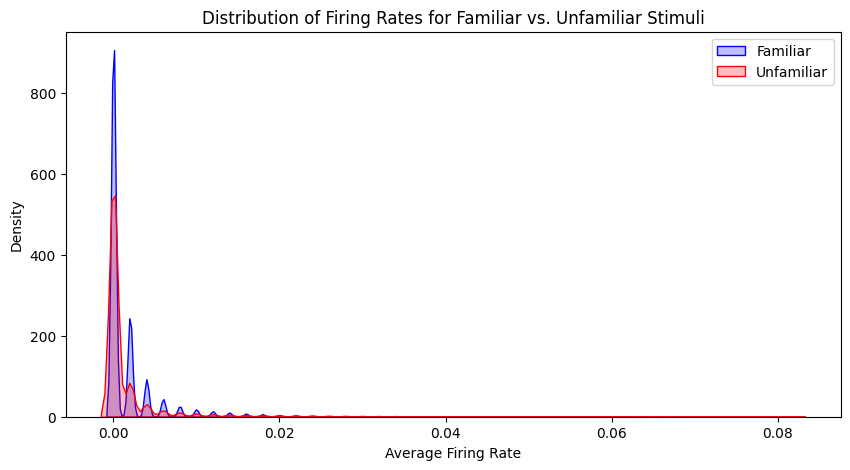

In [162]:
exploratory_analysis(X_familiar, X_unfamiliar)

In [62]:
def wasserstein(X_familiar, X_unfamiliar):
    # Compute the Wasserstein Distance
    wd = wasserstein_distance(X_familiar, X_unfamiliar)
    print(f"Wasserstein Distance between familiar and unfamiliar firing distributions: {wd:.4f}")

Wasserstein Distance between familiar and unfamiliar firing distributions:


Wasserstein distance (Earth Mover's Distance) measures the minimum effort to transform one distribution into another. It captures mean shifts and is sensitive to overall displacements, even when distributions overlap.


- Mean (0.0010)
→ Very small difference in per-neuron average firing rates across conditions.
Suggests that individual neurons' firing rates are not very informative on their own.

- Sum (0.5646)
→ Moderate separation. Summed total activity over neurons captures some global difference in how familiar vs unfamiliar stimuli activate the brain.
Likely useful for classification.

- Fourier (0.1452)
→ Frequency-domain features show slight class differences, possibly due to differences in stimulus-driven rhythms.
May be secondary or supporting features.

- PCA (0.8245)
→ Largest separation. PCA reveals latent, highly differentiating patterns across neurons and time that align well with the familiar/unfamiliar split.
Likely the most powerful representation for classification.

In [68]:
wasserstein(X_familiar, X_unfamiliar)

Wasserstein Distance between familiar and unfamiliar firing distributions: 0.8245


In [69]:
def kl_divergence(X_familiar, X_unfamiliar):
    # Estimate probability densities
    hist_familiar, bins_familiar = np.histogram(X_familiar, bins=50, density=True) # Bins are needed for some reason
    hist_unfamiliar, bins_unfamiliar = np.histogram(X_unfamiliar, bins=50, density=True)

    # Normalize to get probability distributions
    hist_familiar += 1e-10  # Avoid zero probabilities
    hist_unfamiliar += 1e-10
    hist_familiar /= np.sum(hist_familiar)
    hist_unfamiliar /= np.sum(hist_unfamiliar)

    # Compute KL divergence
    kl_div = entropy(hist_familiar, hist_unfamiliar)
    print(f"KL Divergence between distributions: {kl_div:.4f}")

KL Divergence between distributions:

KL divergence measures how one distribution diverges from another in terms of shape and spread. It's useful when you're interested in distributional differences that go beyond just the mean. Especially when the data is skewed or multi-modal.


- Mean (0.7922)
Better than Wasserstein suggested. Though average firing is subtle, the distributional shape is still distinct.

- Sum (0.1175)
Surprisingly low divergence despite moderate Wasserstein distance. Suggests summed responses have similar distribution shapes, but shifted means.

- Fourier (1.5781)
Captures differences in temporal frequency structure. Suggests unfamiliar stimuli may differ in rhythmicity.
Complementary feature set.

- PCA (5.0792)
Strongest divergence. PCA uncovers latent dimensions with high class-separability.
Highly informative for classification.

In [83]:
kl_divergence(X_familiar, X_unfamiliar)

KL Divergence between distributions: 0.1175


In [142]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42, stratify=y)


# Initialize and train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)

Plots a confusion matrix to visualize true vs. predicted labels.

Rows: actual classes, Columns: predicted classes.

Justification for Logistic Regression:

- Simple, interpretable, and works well with linearly separable data.

- Useful baseline for comparison with more complex classifiers.

- Efficient for high-dimensional inputs like PCA-transformed data.

In [102]:
def confusion(y_test, y_pred):
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Familiar", "Unfamiliar"], yticklabels=["Familiar", "Unfamiliar"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

- Mean:

    - True Negative (TN): 73
    - False Positive (FP): 7
    - False Negative (FN): 31
    - True Positive (TP): 49

    - Very high TN → good at recognizing familiar stimuli.

    - Moderate FN → often misses unfamiliar ones.

    - Balanced but conservative model.

- Sum:

    - True Negative (TN): 51
    - False Positive (FP): 29
    - False Negative (FN): 28
    - True Positive (TP): 52

    - Lower TN, higher FP → tends to overdetect unfamiliarity.

    - Balanced TP and FN → catches more unfamiliar but at cost of false alarms.

- Fourier:

    - True Negative (TN): 64
    - False Positive (FP): 16
    - False Negative (FN): 9
    - True Positive (TP): 71

    - Highest TP and lowest FN → best at detecting unfamiliar stimuli.

    - Moderate FP → some overdetection.

    - Most sensitive to novelty.

- PCA:

    - True Negative (TN): 69
    - False Positive (FP): 11
    - False Negative (FN): 53
    - True Positive (TP): 27

    - High TN, but very high FN and low TP → fails to detect unfamiliar stimuli.

    - Likely underfits or loses class-relevant information in projection.

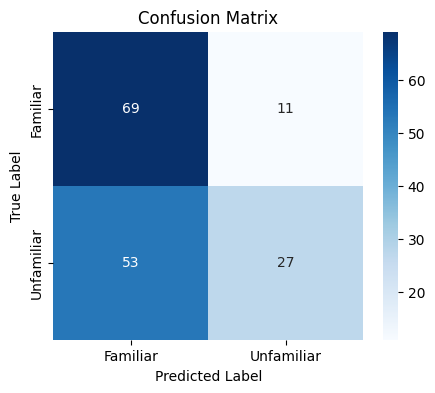

In [118]:
confusion(y_test, y_pred)

Visualizes the top 10 most important neurons based on logistic regression coefficients. Assumes the model was trained on features representing individual neurons (e.g., mean_x)

Justification for Using Logistic Regression Coefficients:

- Logistic regression is a linear model; each coefficient directly reflects a feature’s (neuron’s) influence on the prediction.

- Taking the absolute value shows how strongly a neuron contributes, regardless of direction (toward familiar or unfamiliar).

- This method is simple, interpretable, and allows us to identify biologically relevant neurons for further study.

In [24]:
def feature_importance():
    # Feature Importance

    # Get logistic regression coefficients
    neuron_importance = np.abs(model.coef_).flatten()

    # Plot top 10 neurons
    top_neurons = np.argsort(neuron_importance)[-10:]
    plt.figure(figsize=(10, 5))
    plt.bar(range(10), neuron_importance[top_neurons], tick_label=top_neurons)
    plt.xlabel("Neuron Index")
    plt.ylabel("Importance")
    plt.title("Top 10 Most Important Neurons for Classification")
    plt.show()

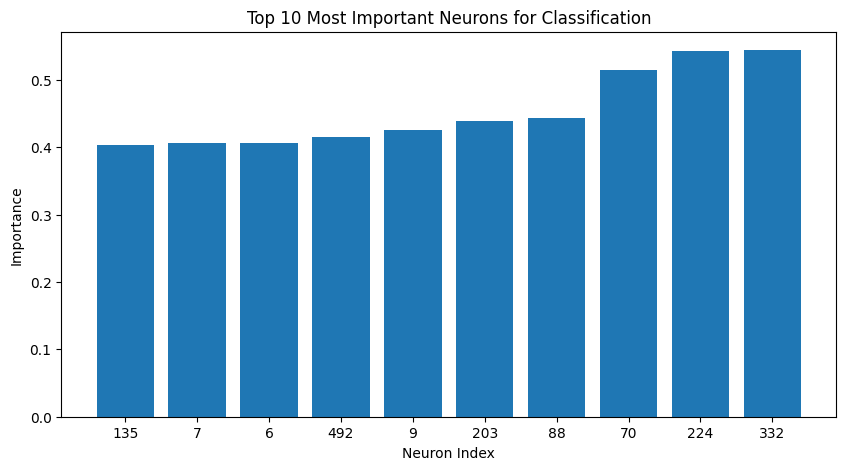

In [25]:
feature_importance()

Evaluates model performance using accuracy, F1-score, and detailed classification metrics:

Justification for Metrics:

- Accuracy: This gives an overall measure of how often the model is correct. It is good when classes are balanced, but might be misleading if the data is imbalanced.

- Precision: The proportion of true positive predictions out of all predicted positives.

- Recall: The proportion of true positive predictions out of all actual positives

- F1-score: This is especially useful when class imbalance exists, as it balances Precision (correct positive predictions) and Recall (capture of actual positives). F1-score is better than accuracy when the cost of missing a class (false negatives) or making false positive predictions is high.



In [125]:
def performance(y_test, y_pred):
    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Compute F1-score, precison and recall
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Print classification report (includes Precision, Recall, and F1-score)
    print("\nClassification Report: \n" + classification_report(y_test, y_pred))

    # Print specific metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    

Mean:
- Accuracy: 0.7625 
- Precision: 0.8750 
- Recall: 0.6125 
- F1-score: 0.7206
- The model is cautious in predicting "unfamiliar" and prefers to avoid false positives, but this comes at the cost of missing many actual unfamiliar stimuli. It performs reliably when it does make a positive prediction, but isn't very sensitive overall.

Sum:
- Accuracy: 0.6438 
- Precision: 0.6420 
- Recall: 0.6500 
- F1-score: 0.6460
- This model treats familiar and unfamiliar stimuli almost equally, but lacks strong discriminatory power. Its performance is average across all metrics, suggesting it doesn’t capture meaningful distinctions in the summed neural activity.

Fourier: 
- Accuracy: 0.8438 
- Precision: 0.8161 
- Recall: 0.8875 
- F1-score: 0.8503
- This model catches the most unfamiliar stimuli while keeping false alarms relatively low. Ideal if missing unfamiliar stimuli is costly.

PCA:
- Accuracy: 0.6250 
- Precision: 0.7778 
- Recall: 0.3500 
- F1-score: 0.4828
- It predicts "unfamiliar" with high precision but misses the majority of unfamiliar cases. Likely over-compressed or loses important temporal structure.



In [143]:
performance(y_test, y_pred)


Classification Report: 
              precision    recall  f1-score   support

           0       0.58      0.90      0.71        80
           1       0.78      0.35      0.48        80

    accuracy                           0.62       160
   macro avg       0.68      0.62      0.59       160
weighted avg       0.68      0.62      0.59       160

Accuracy: 0.6250
Precision: 0.7778
Recall: 0.3500
F1-score: 0.4828
